# Overview

The objective of this project is to design an automated feedback system which provides music students with formative, elaborated feedback for music practice. 

This notebook shows how the full compareMusic pipeline works on a real practice recording:
1. load the reference audio and the response audio files recorded during practice
2. transcribe the audio files into MIDI format using the transcription and post-processing pipeline developed in Phase2 
3. pass the reference MIDI and response MIDI into the MIDI comparison pipeline developed in Phase1 to get the feedback messages
- additionally provides visualisation plots to show the alignment result between the reference and the performance(response)

Evaluation and analysis of the pipeline's performance are in the other summary notebooks.

## 1. Setup and Load the audio

In [1]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

from evaluation_function.audio_processing import (
    load_basic_pitch_model,
    transcription_pipeline,
)
from evaluation_function.compare_MIDI import (
    compare_performance_ED,
    normalize_start_times,
    group_notes_into_events,
    DEFAULT_CHORD_ONSET_WINDOW,
)

from notebooks.utils.nasap_alignment_evaluation import plot_alignment

scikit-learn version 1.9.0 is not supported. Minimum required version: 0.17. Maximum required version: 1.5.1. Disabling scikit-learn conversion API.
/Users/jz7125/compareMusic/.venv/lib/python3.11/site-packages/resampy/filters.py:50: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


Load the data:

- Response: 2 audio files of the same song recorded by my supervisor during daily practice.
- Reference: using a tool called 'soundslice' to generate audio file from the music score provided by my supervisor.

In [2]:
# Find the project root directory by looking for the pyproject.toml file
path = Path.cwd().resolve()
while not (path / "pyproject.toml").exists():
    path = path.parent
PROJECT_ROOT = path
DATA_ROOT = PROJECT_ROOT / "data" / "real_recordings"

# path to the audio files and reference MIDI file
PRACTICE01_PATH = DATA_ROOT / "practice_01.m4a"
PRACTICE02_PATH = DATA_ROOT / "practice_02.m4a"
REFERENCE_AUDIO_PATH = DATA_ROOT / "reference_score.m4a"

assert PRACTICE01_PATH.exists(), f"Audio file not found: {PRACTICE01_PATH}"
assert PRACTICE02_PATH.exists(), f"Audio file not found: {PRACTICE02_PATH}"
assert REFERENCE_AUDIO_PATH.exists(), f"Reference MIDI not found: {REFERENCE_AUDIO_PATH}"

print("Practice1 file:", PRACTICE01_PATH)
print("Practice2 file:", PRACTICE02_PATH)
print("Reference score:", REFERENCE_AUDIO_PATH)

Practice1 file: /Users/jz7125/compareMusic/data/real_recordings/practice_01.m4a
Practice2 file: /Users/jz7125/compareMusic/data/real_recordings/practice_02.m4a
Reference score: /Users/jz7125/compareMusic/data/real_recordings/reference_score.m4a


## 2. Audio-to-MIDI Transcription

Both the practice recording and the reference audio are transcribed using the same audio-to-MIDI pipeline, therefore transcrition error may occur in either side. A manually-inspected reference MIDI generated directly from the music score would be preferable.

In [3]:
# Load the Basic Pitch model once, reuse it for both files
basic_pitch_model = load_basic_pitch_model()

# Transcribe the practice recording 01
response1, predicted_notes1, response_runtime_seconds1 = transcription_pipeline(
    PRACTICE01_PATH,
    basic_pitch_model,
    apply_postprocessing=True,
)

# Transcribe the practice recording 02
response2, predicted_notes2, response_runtime_seconds2 = transcription_pipeline(
    PRACTICE02_PATH,
    basic_pitch_model,
    apply_postprocessing=True,
)

# Transcribe the reference recording
reference, reference_notes, reference_runtime_seconds = transcription_pipeline(
    REFERENCE_AUDIO_PATH,
    basic_pitch_model,
    apply_postprocessing=True,
)

print(f"Transcribed practice recording 01: {len(predicted_notes1)} notes "
      f"in {response_runtime_seconds1:.1f}s")
print(f"Transcribed practice recording 02: {len(predicted_notes2)} notes "
      f"in {response_runtime_seconds2:.1f}s")
print(f"Transcribed reference recording: {len(reference_notes)} notes "
      f"in {reference_runtime_seconds:.1f}s")

Transcribed practice recording 01: 97 notes in 2.6s
Transcribed practice recording 02: 87 notes in 0.6s
Transcribed reference recording: 163 notes in 0.4s


Visualise the transcribed MIDI using Piano Roll

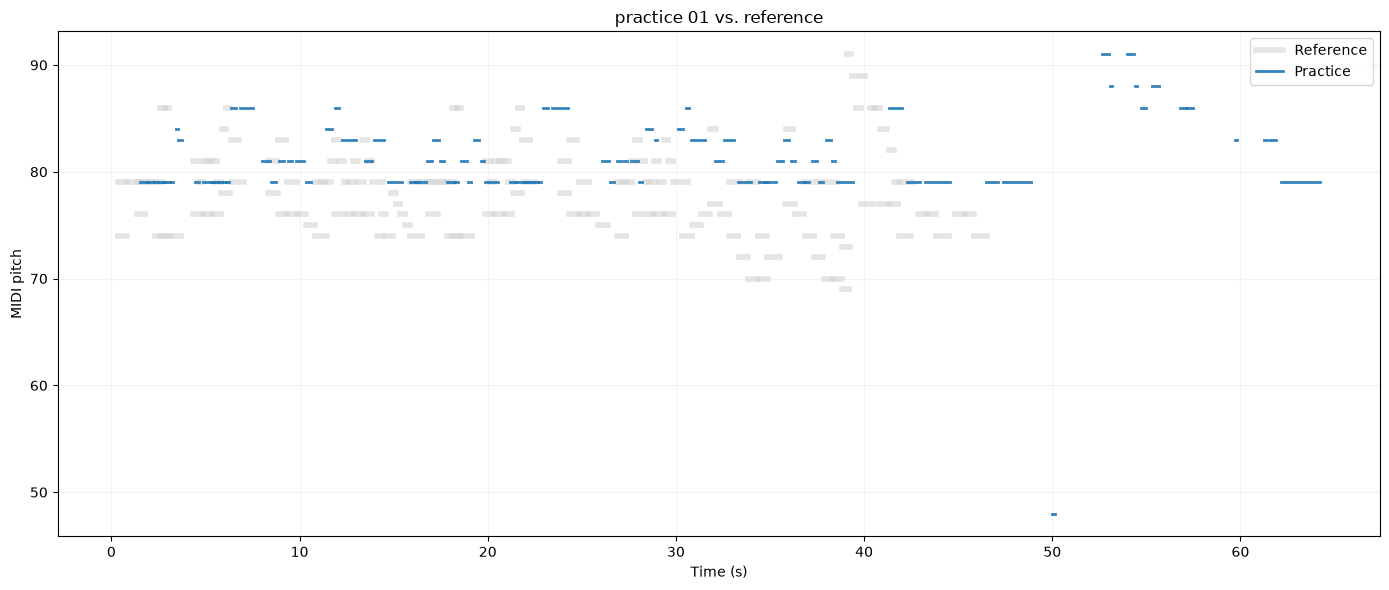

In [4]:
def plot_piano_roll_comparison(predicted_notes, reference_notes, title="Piano roll comparison"):
    fig, ax = plt.subplots(figsize=(14, 6))

    for note in reference_notes:
        offset = note["start"] + note["duration"]
        ax.plot(
            [note["start"], offset],
            [note["pitch"], note["pitch"]],
            linewidth=4,
            alpha=0.6,
            color="lightgray",
            label="Reference",
        )

    for note in predicted_notes:
        offset = note["onset"] + note["duration"]
        ax.plot(
            [note["onset"], offset],
            [note["pitch"], note["pitch"]],
            linewidth=2,
            alpha=0.9,
            color="tab:blue",
            label="Practice",
        )

    handles, labels = ax.get_legend_handles_labels()
    unique = dict(zip(labels, handles))
    ax.legend(unique.values(), unique.keys(), loc="upper right")

    ax.set_xlabel("Time (s)")
    ax.set_ylabel("MIDI pitch")
    ax.set_title(title)
    ax.grid(alpha=0.15)
    plt.tight_layout()
    plt.show()

plot_piano_roll_comparison(predicted_notes1, reference["notes"], title="practice 01 vs. reference")

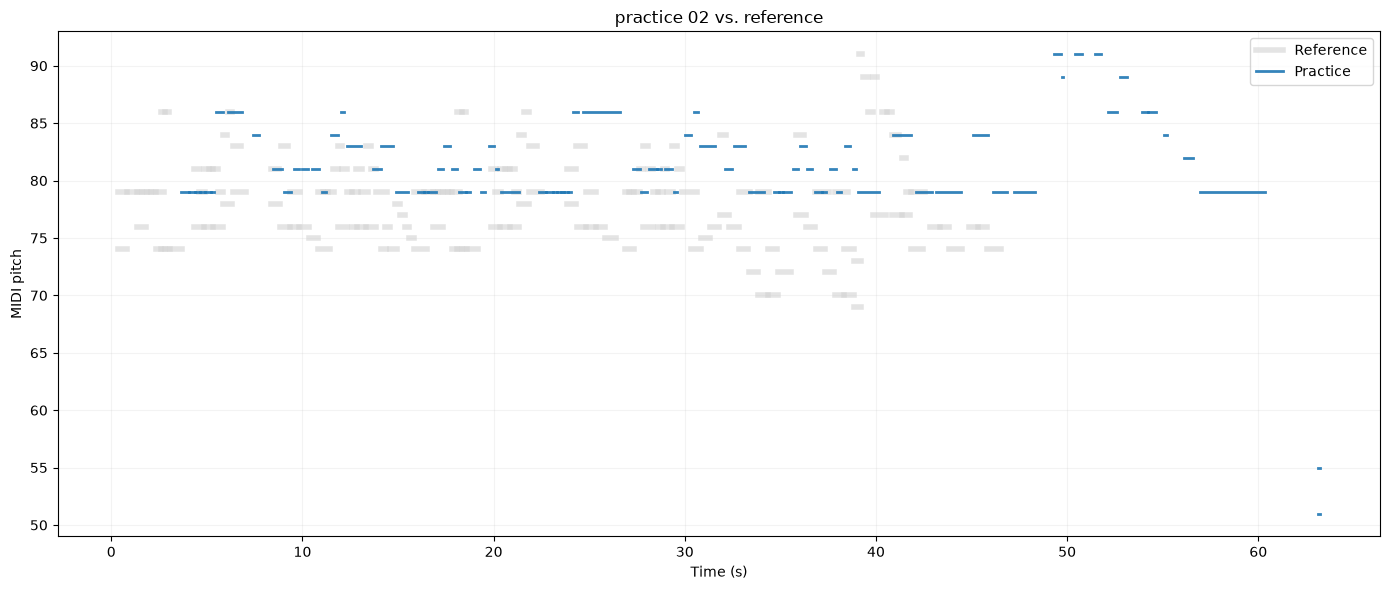

In [5]:
plot_piano_roll_comparison(predicted_notes2, reference["notes"], title="practice 02 vs. reference")

## 3. Compare reference and response to generate feedback messages

The two practice recordings were recorded on the same day, the level of performance is the same (similar patterns observed from the piano roll), therefore here just generate the feedback for practice 01 for presentation.

In [6]:
result1 = compare_performance_ED(response1, reference)
print(result1.feedback_message)

Practice Summary
Note accuracy needs more practice. Practice each short passage at a slower tempo, check each note carefully, mind the fingering during practice. Then move on to the next passage when you feel confident with the current one.
Timing consistency needs more practice. You can slow down in your next practice session and listen carefully for notes that arrive too early or too late. A metronome can help you play each note at the right time and hence make the rhythm more steady.
Simultaneous notes are often hard to play correctly at the beginning. Pay attention to the fingering and hand position when playing these chords. You may find it helpful to practice each chord separately first and make sure all required notes sound together. Then you can reconnect the chords to their surrounding sections and practice at a slower tempo carefully. 

Tempo
Your overall tempo was slower than the reference. This is not necessarily a problem, and it is a good idea to play slowly while learnin

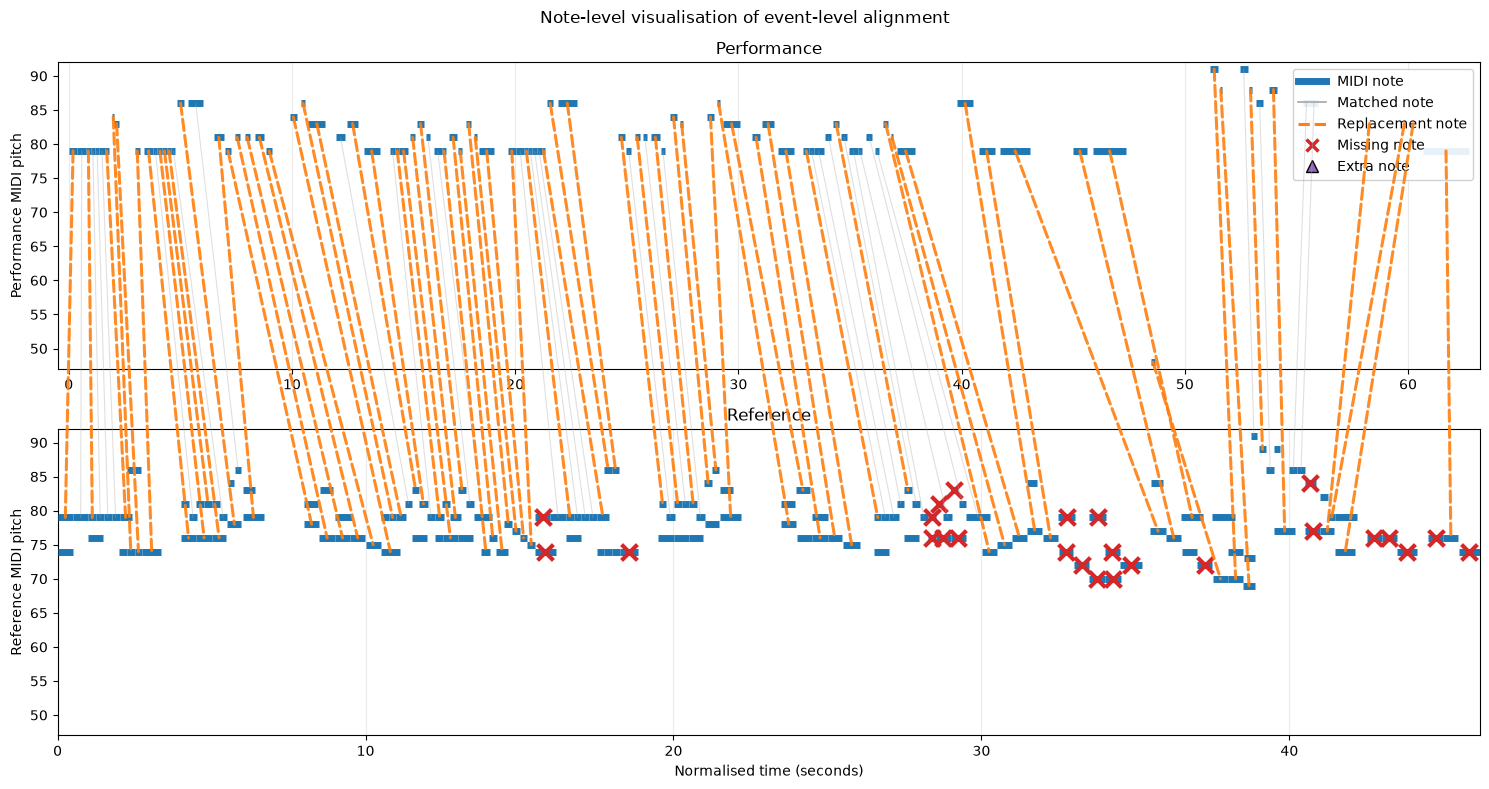

Selected operations: 114
Note connectors: 97
Missing note markers: 25
Extra note markers: 0


In [7]:
# Regenerate the grouped events compare_performance_ED used internally --
# same two calls as its own Step 0, with the same default chord_onset_window
# (change this if you passed a custom chord_onset_window to compare_performance_ED above)
response_events = group_notes_into_events(
    normalize_start_times(response1["notes"]), DEFAULT_CHORD_ONSET_WINDOW
)
ref_events = group_notes_into_events(
    normalize_start_times(reference["notes"]), DEFAULT_CHORD_ONSET_WINDOW
)

# Zoom into the whole piece: 0 to the last reference note's end time
ref_end = max(
    note["start"] + note["duration"]
    for event in ref_events
    for note in event["notes"]
)

# Usage
plot_alignment(ref_events, response_events, result1.event_details, ref_start=0.0, ref_end=ref_end)